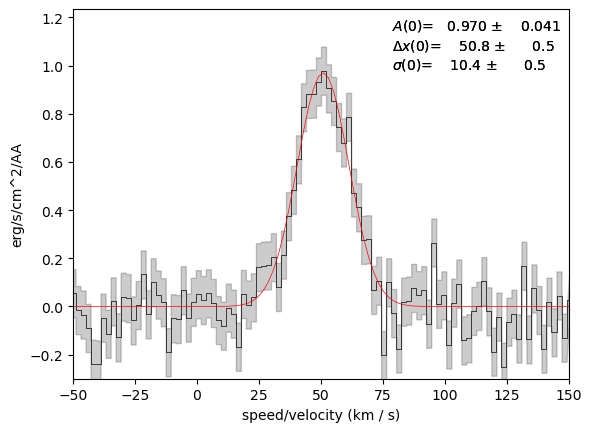

In [1]:
import numpy as np
import pyspeckit

xaxis = np.linspace(-50, 150, 100)
sigma = 10.
center = 50.
synth_data = np.exp(-(xaxis - center) ** 2 / (sigma ** 2 * 2.))

stddev = 0.1
noise = np.random.randn(xaxis.size) * stddev
error = stddev * np.ones_like(synth_data)
data = noise + synth_data

sp = pyspeckit.Spectrum(data=data, error=error, xarr=xaxis, xarrkwargs={'unit': 'km/s'}, unit='erg/s/cm^2/AA')
sp.plotter()

sp.specfit(fittype='gaussian')

amplitude_guess = data.max()
center_guess = (data * xaxis).sum() / data.sum()
width_guess = (data.sum() / amplitude_guess / (2 * np.pi)) ** 0.5
guesses = [amplitude_guess, center_guess, width_guess]
sp.specfit(fittype='gaussian', guesses=guesses)

sp.plotter(errstyle='fill')
sp.specfit.plot_fit()


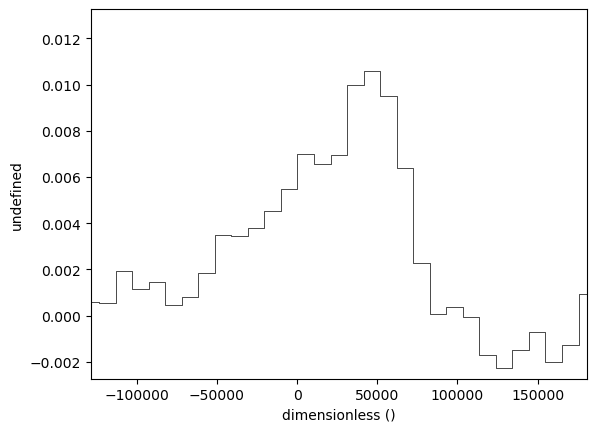

In [2]:
from astropy.io import fits
import pyspeckit
from pyspeckit.spectrum.units import SpectroscopicAxis
import numpy as np

hdul = fits.open('ngc6503vopt.fits')
cube = np.squeeze(hdul[0].data)  # Shape becomes (31, 256, 256)
header = hdul[0].header

z, y, x = cube.shape
spectrum_1d = cube[:, y // 2, x // 2]  # shape (31,)

crval = header.get('CRVAL3', 0)
cdelt = header.get('CDELT3', 1)
crpix = header.get('CRPIX3', 1)


xarr_vals = crval + (np.arange(len(spectrum_1d)) - (crpix - 1)) * cdelt
xarr = SpectroscopicAxis(xarr_vals, unit=header.get('CUNIT3', ''))

sp = pyspeckit.Spectrum(data=spectrum_1d, xarr=xarr)
sp.plotter()
